# Bank Marketing Analytics & Subscription Prediction

## 02 — Exploratory Data Analysis

This notebook explores the cleaned UCI Bank Marketing dataset to identify customer, campaign, and historical-contact patterns associated with term-deposit subscription.

### Objectives

- Examine the target-class distribution.
- Analyze numerical and categorical feature distributions.
- Compare subscribers and non-subscribers.
- Calculate segment-level subscription rates.
- Identify skewness, unusual values, and potentially informative patterns.
- Analyze the `duration` feature while documenting its data-leakage risk.
- Translate descriptive findings into business-oriented observations.

> Important: The analysis in this notebook is observational. Associations found in the data should not be interpreted as causal effects.

In [45]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


def locate_project_root(start_path: Path) -> Path:
    """Locate the project root from the current notebook directory."""
    current_path = start_path.resolve()

    for candidate in [current_path, *current_path.parents]:
        expected_file = (
            candidate
            / "data"
            / "processed"
            / "bank_marketing_clean.csv"
        )

        if expected_file.exists():
            return candidate

    raise FileNotFoundError(
        "Project root could not be located. "
        "Run src/data_cleaning.py before executing this notebook."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "bank_marketing_clean.csv"
)

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"Figures directory: {FIGURES_DIR}")

Project root: C:\Users\omary\Documents\VS Code\bank-marketing-analytics-ml
Dataset path: C:\Users\omary\Documents\VS Code\bank-marketing-analytics-ml\data\processed\bank_marketing_clean.csv
Figures directory: C:\Users\omary\Documents\VS Code\bank-marketing-analytics-ml\reports\figures


## 1. Load and Validate the Cleaned Dataset

The cleaned dataset contains the original banking and campaign variables, while the original text target `y` has been replaced by the binary target `subscribed`.

Target encoding:

- `0`: the client did not subscribe.
- `1`: the client subscribed.

In [46]:
data = pd.read_csv(DATA_PATH)

EXPECTED_SHAPE = (45_211, 17)

EXPECTED_COLUMNS = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "balance",
    "housing",
    "loan",
    "contact",
    "day",
    "month",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "poutcome",
    "subscribed",
]

assert data.shape == EXPECTED_SHAPE
assert data.columns.tolist() == EXPECTED_COLUMNS
assert set(data["subscribed"].unique()) == {0, 1}

print(f"Dataset shape: {data.shape}")
print(f"Duplicate rows: {int(data.duplicated().sum())}")
print(f"Missing cells: {int(data.isna().sum().sum())}")

display(data.head())

Dataset shape: (45211, 17)
Duplicate rows: 0
Missing cells: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0


In [47]:
TARGET_COLUMN = "subscribed"

NUMERIC_COLUMNS = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous",
]

CATEGORICAL_COLUMNS = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome",
]

PRE_CALL_FEATURES = [
    column
    for column in data.columns
    if column not in {TARGET_COLUMN, "duration"}
]

print(f"Numerical features: {len(NUMERIC_COLUMNS)}")
print(f"Categorical features: {len(CATEGORICAL_COLUMNS)}")
print(f"Pre-call model features: {len(PRE_CALL_FEATURES)}")

print("\nFeature excluded from the pre-call model:")
print("- duration")

Numerical features: 7
Categorical features: 9
Pre-call model features: 15

Feature excluded from the pre-call model:
- duration


## 2. Target-Class Distribution

Understanding the target distribution is essential because a strongly imbalanced target affects model evaluation and business interpretation.

A naive model that predicts the majority class for every client could achieve high accuracy while identifying no actual subscribers.

In [48]:
target_summary = (
    data[TARGET_COLUMN]
    .value_counts()
    .sort_index()
    .rename_axis(TARGET_COLUMN)
    .reset_index(name="count")
)

target_summary["label"] = target_summary[TARGET_COLUMN].map(
    {
        0: "No subscription",
        1: "Subscription",
    }
)

target_summary["percentage"] = (
    target_summary["count"]
    .div(len(data))
    .mul(100)
    .round(2)
)

display(
    target_summary[
        [
            TARGET_COLUMN,
            "label",
            "count",
            "percentage",
        ]
    ]
)

,subscribed,label,count,percentage
0,0,No subscription,39922,88.30
1,1,Subscription,5289,11.70


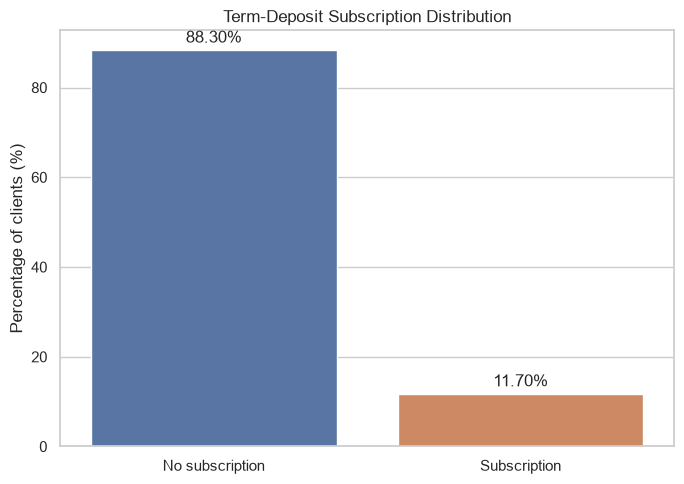

In [49]:
figure, axis = plt.subplots(figsize=(7, 5))

sns.barplot(
    data=target_summary,
    x="label",
    y="percentage",
    hue="label",
    legend=False,
    ax=axis,
)

axis.set_title("Term-Deposit Subscription Distribution")
axis.set_xlabel("")
axis.set_ylabel("Percentage of clients (%)")

for container in axis.containers:
    axis.bar_label(
        container,
        fmt="%.2f%%",
        padding=3,
    )

plt.tight_layout()
plt.show()

### Initial Target Observation

Only 11.7% of the contacted clients subscribed to the term deposit.

This class imbalance has two important implications:

1. Accuracy will not be sufficient as the primary machine-learning evaluation metric.
2. Future model evaluation should include precision, recall, F1-score, ROC-AUC, and especially PR-AUC.

The appropriate balance between precision and recall will depend on the bank's campaign cost and customer-contact strategy.

## 3. Numerical Feature Overview

Descriptive statistics provide an initial view of central tendency, variability, extreme values, and potentially skewed distributions.

The IQR-based outlier assessment performed previously is diagnostic only. Legitimate banking values should not be removed solely because they are statistically unusual.

In [50]:
numerical_summary = (
    data[NUMERIC_COLUMNS]
    .describe()
    .transpose()
)

numerical_summary["median"] = (
    data[NUMERIC_COLUMNS]
    .median()
)

numerical_summary["skewness"] = (
    data[NUMERIC_COLUMNS]
    .skew()
)

numerical_summary = numerical_summary[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "skewness",
    ]
]

display(numerical_summary)

,count,mean,median,std,min,25%,50%,75%,max,skewness
age,"45,211.00",40.94,39.00,10.62,18.00,33.00,39.00,48.00,95.00,0.68
balance,"45,211.00","1,362.27",448.00,"3,044.77","-8,019.00",72.00,448.00,"1,428.00","102,127.00",8.36
day,"45,211.00",15.81,16.00,8.32,1.00,8.00,16.00,21.00,31.00,0.09
duration,"45,211.00",258.16,180.00,257.53,0.00,103.00,180.00,319.00,"4,918.00",3.14
campaign,"45,211.00",2.76,2.00,3.10,1.00,1.00,2.00,3.00,63.00,4.90
pdays,"45,211.00",40.20,-1.00,100.13,-1.00,-1.00,-1.00,-1.00,871.00,2.62
previous,"45,211.00",0.58,0.00,2.30,0.00,0.00,0.00,0.00,275.00,41.85


In [51]:
def classify_skewness(skewness: float) -> str:
    """Classify distribution skewness using common descriptive thresholds."""
    absolute_skewness = abs(skewness)

    if absolute_skewness < 0.5:
        return "Approximately symmetric"

    if absolute_skewness < 1:
        return "Moderately skewed"

    return "Highly skewed"


skewness_summary = (
    data[NUMERIC_COLUMNS]
    .skew()
    .rename("skewness")
    .reset_index()
    .rename(columns={"index": "feature"})
)

skewness_summary["absolute_skewness"] = (
    skewness_summary["skewness"].abs()
)

skewness_summary["interpretation"] = (
    skewness_summary["skewness"]
    .apply(classify_skewness)
)

skewness_summary = (
    skewness_summary
    .sort_values(
        "absolute_skewness",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(skewness_summary)

,feature,skewness,absolute_skewness,interpretation
0,previous,41.85,41.85,Highly skewed
1,balance,8.36,8.36,Highly skewed
2,campaign,4.90,4.90,Highly skewed
3,duration,3.14,3.14,Highly skewed
4,pdays,2.62,2.62,Highly skewed
5,age,0.68,0.68,Moderately skewed
6,day,0.09,0.09,Approximately symmetric


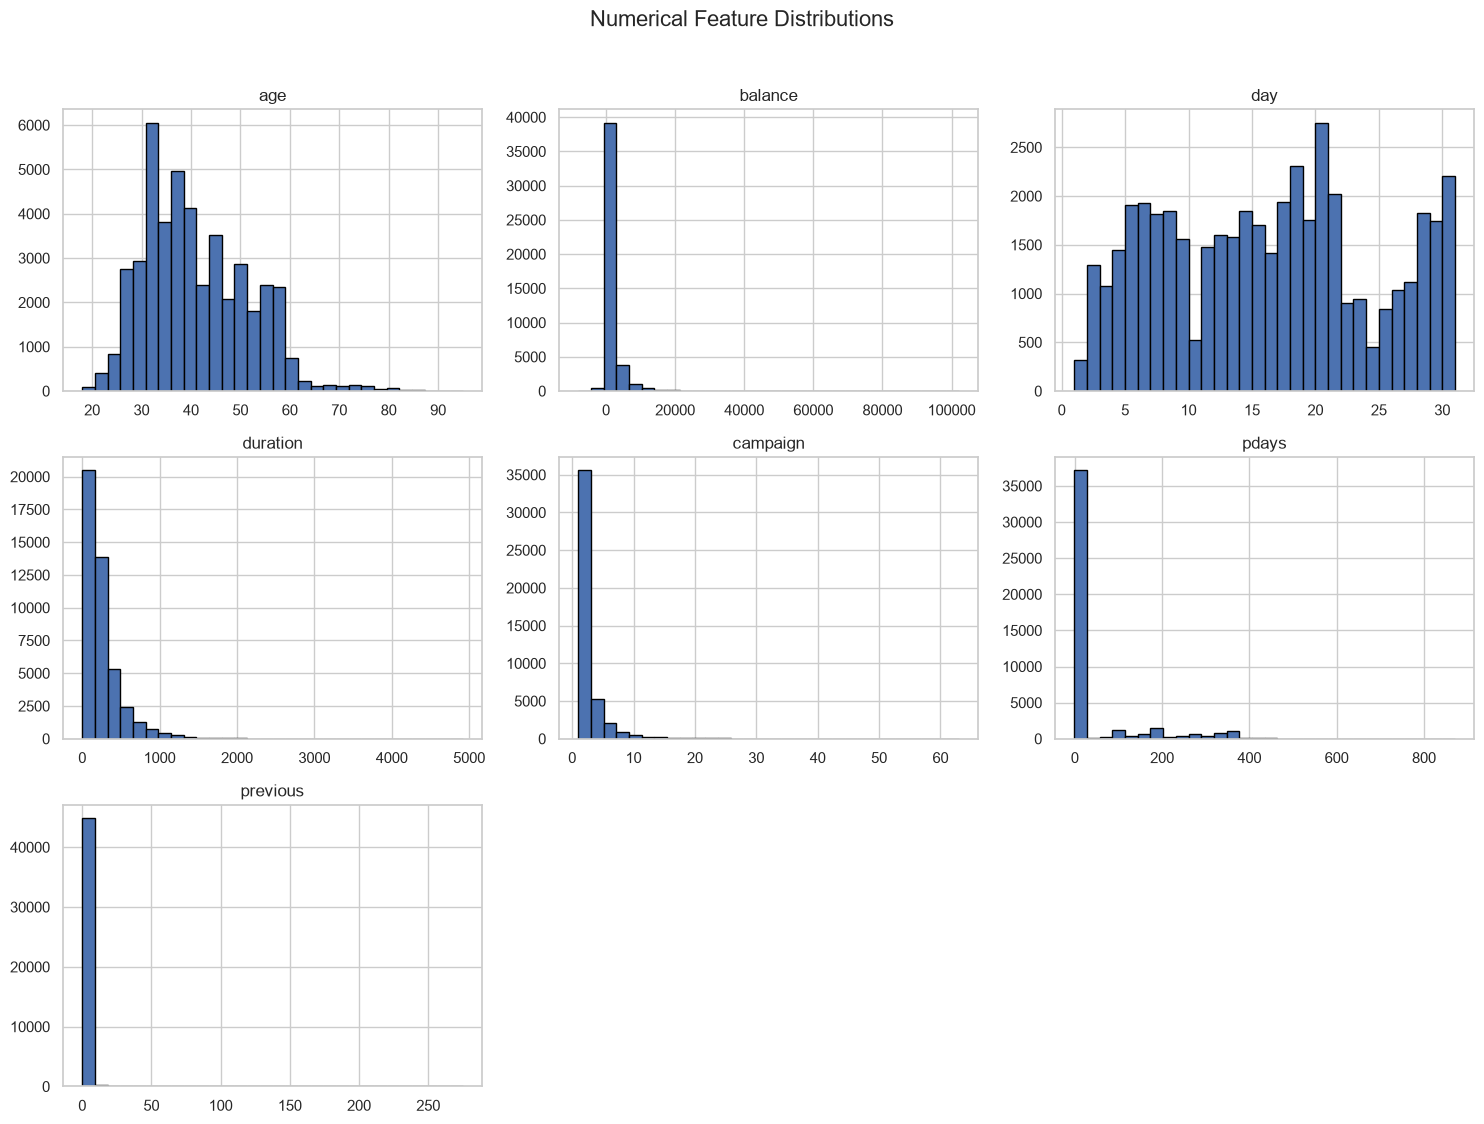

In [52]:
data[NUMERIC_COLUMNS].hist(
    bins=30,
    figsize=(15, 11),
    edgecolor="black",
)

plt.suptitle(
    "Numerical Feature Distributions",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()
plt.show()

### Notes on Special Numerical Variables

- Negative `balance` values may represent overdrafts or debt and are not automatically invalid.
- `pdays = -1` is a meaningful sentinel value indicating that the client was not previously contacted.
- `previous = 0` is expected for clients with no prior campaign contact.
- High values in `campaign` may represent repeated contact attempts rather than data-entry errors.
- `duration` may be highly informative descriptively, but it is unavailable before the call ends and must not be used in the primary pre-call model.

## 4. Numerical Features by Subscription Status

Group-level descriptive statistics help identify differences between subscribers and non-subscribers.

These are observational comparisons and do not establish that a numerical feature causes subscription.

In [53]:
numerical_by_target = (
    data
    .groupby(TARGET_COLUMN)[NUMERIC_COLUMNS]
    .agg(["mean", "median"])
    .transpose()
)

numerical_by_target.columns = [
    "non_subscribers",
    "subscribers",
]

numerical_by_target[
    "difference_subscribers_minus_non_subscribers"
] = (
    numerical_by_target["subscribers"]
    - numerical_by_target["non_subscribers"]
)

display(numerical_by_target)

non_subscribers  subscribers  \
age      mean              40.84        41.67   
         median            39.00        38.00   
balance  mean           1,303.71     1,804.27   
         median           417.00       733.00   
day      mean              15.89        15.16   
         median            16.00        15.00   
duration mean             221.18       537.29   
         median           164.00       426.00   
campaign mean               2.85         2.14   
         median             2.00         2.00   
pdays    mean              36.42        68.70   
         median            -1.00        -1.00   
previous mean               0.50         1.17   
         median             0.00         0.00   

                 difference_subscribers_minus_non_subscribers  
age      mean                                            0.83  
         median                                         -1.00  
balance  mean                                          500.55  
         median                                        316.00  
day      mean                                           -0.73  
         median                                         -1.00  
duration mean                                          316.11  
         median                                        262.00  
campaign mean                                           -0.71  
         median                                          0.00  
pdays    mean                                           32.28  
         median                                          0.00  
previous mean                                            0.67  
         median                                          0.00

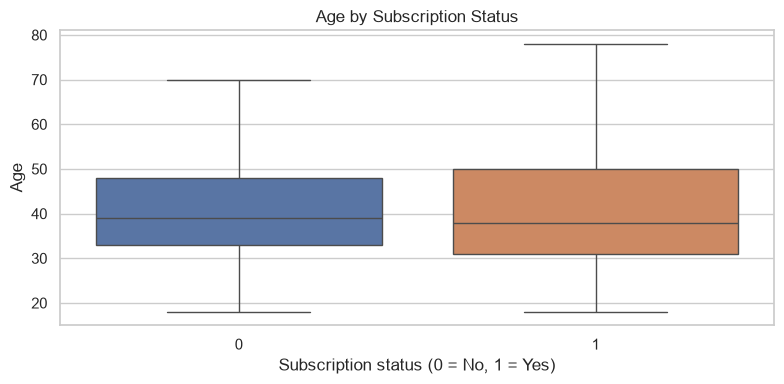

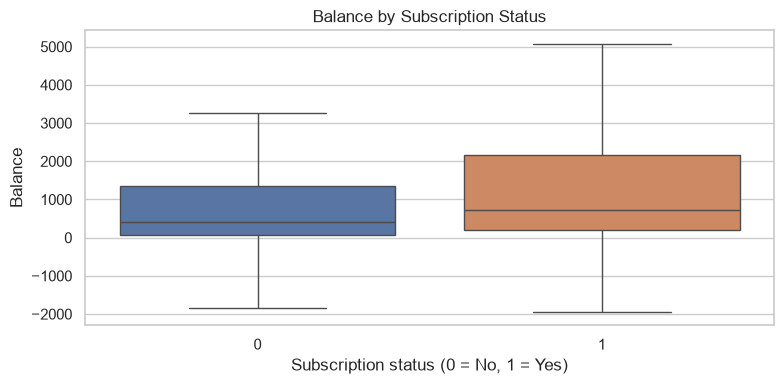

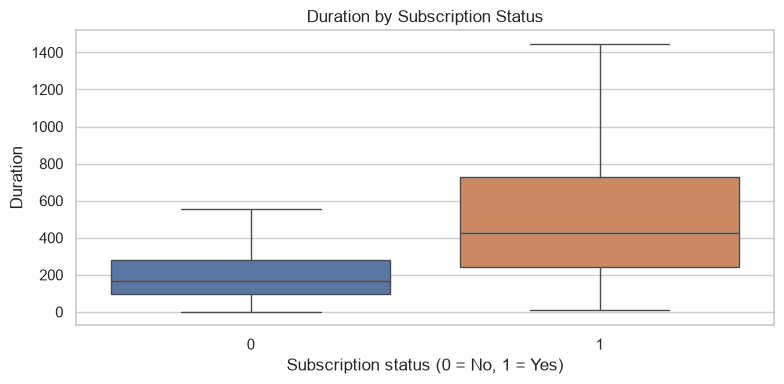

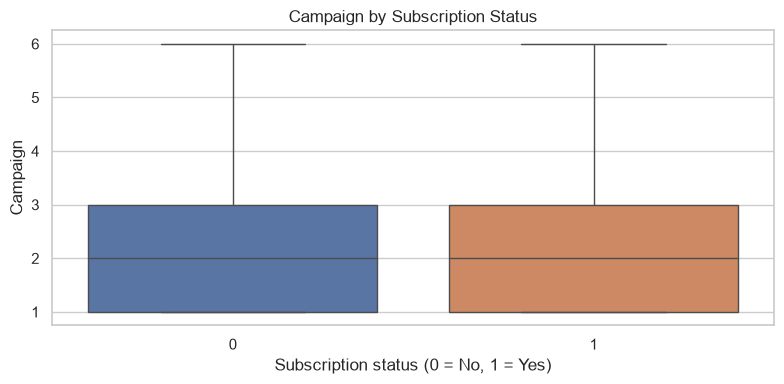

In [54]:
features_for_boxplots = [
    "age",
    "balance",
    "duration",
    "campaign",
]

for feature in features_for_boxplots:
    figure, axis = plt.subplots(figsize=(8, 4))

    sns.boxplot(
        data=data,
        x=TARGET_COLUMN,
        y=feature,
        hue=TARGET_COLUMN,
        legend=False,
        showfliers=False,
        ax=axis,
    )

    axis.set_title(
        f"{feature.title()} by Subscription Status"
    )

    axis.set_xlabel(
        "Subscription status (0 = No, 1 = Yes)"
    )

    axis.set_ylabel(feature.title())

    plt.tight_layout()
    plt.show()

## Preliminary Numerical Findings

The numerical analysis suggests that several features have skewed or zero-inflated distributions, so means should be interpreted alongside medians.

Potential differences between subscribers and non-subscribers are descriptive at this stage. Statistical significance and effect sizes will be assessed later in the statistical-analysis notebook.

The `duration` feature is expected to show a strong association with subscription, but this association must be interpreted carefully because the feature is only known after the call has taken place.

## 5. Categorical Feature Overview

Categorical variables describe customer characteristics, financial obligations, communication channels, campaign timing, and previous campaign outcomes.

For each feature, the analysis examines:

- Segment size.
- Number of subscribers.
- Subscription rate.
- Differences between large and small customer segments.

A high subscription rate in a very small segment should be interpreted carefully because it may not translate into a large number of potential subscribers.

In [55]:
categorical_overview = pd.DataFrame(
    {
        "feature": CATEGORICAL_COLUMNS,
        "unique_categories": [
            data[column].nunique(dropna=False)
            for column in CATEGORICAL_COLUMNS
        ],
        "most_common_category": [
            data[column].mode(dropna=False).iloc[0]
            for column in CATEGORICAL_COLUMNS
        ],
        "most_common_count": [
            data[column].value_counts(dropna=False).iloc[0]
            for column in CATEGORICAL_COLUMNS
        ],
    }
)

categorical_overview["most_common_percentage"] = [
    round(
        data[column]
        .value_counts(
            normalize=True,
            dropna=False,
        )
        .iloc[0]
        * 100,
        2,
    )
    for column in CATEGORICAL_COLUMNS
]

display(categorical_overview)

,feature,unique_categories,most_common_category,most_common_count,most_common_percentage
0,job,12,blue-collar,9732,21.53
1,marital,3,married,27214,60.19
2,education,4,secondary,23202,51.32
3,default,2,no,44396,98.20
4,housing,2,yes,25130,55.58
5,loan,2,no,37967,83.98
6,contact,3,cellular,29285,64.77
7,month,12,may,13766,30.45
8,poutcome,4,unknown,36959,81.75


In [56]:
def subscription_summary_by_category(
    dataframe: pd.DataFrame,
    feature: str,
    category_order: list[str] | None = None,
) -> pd.DataFrame:
    """Summarize segment size and subscription performance."""
    summary = (
        dataframe
        .groupby(
            feature,
            dropna=False,
            observed=True,
        )[TARGET_COLUMN]
        .agg(
            client_count="size",
            subscriber_count="sum",
            subscription_rate="mean",
        )
        .reset_index()
    )

    summary["subscription_rate"] = (
        summary["subscription_rate"]
        .mul(100)
        .round(2)
    )

    summary["share_of_all_clients"] = (
        summary["client_count"]
        .div(len(dataframe))
        .mul(100)
        .round(2)
    )

    if category_order is not None:
        summary[feature] = pd.Categorical(
            summary[feature],
            categories=category_order,
            ordered=True,
        )

        summary = (
            summary
            .sort_values(feature)
            .reset_index(drop=True)
        )
    else:
        summary = (
            summary
            .sort_values(
                "subscription_rate",
                ascending=False,
            )
            .reset_index(drop=True)
        )

    return summary

## 6. Subscription Rate by Job

Job categories may differ in age, income, financial needs, and responsiveness to term-deposit offers.

Both subscription rate and segment size should be considered. A small segment with a high rate may produce fewer total subscriptions than a large segment with a moderate rate.

In [57]:
job_summary = subscription_summary_by_category(
    data,
    "job",
)

display(job_summary)

,job,client_count,subscriber_count,subscription_rate,share_of_all_clients
0,student,938,269,28.68,2.07
1,retired,2264,516,22.79,5.01
2,unemployed,1303,202,15.50,2.88
3,management,9458,1301,13.76,20.92
4,admin.,5171,631,12.20,11.44
5,self-employed,1579,187,11.84,3.49
6,unknown,288,34,11.81,0.64
7,technician,7597,840,11.06,16.80
8,services,4154,369,8.88,9.19
9,housemaid,1240,109,8.79,2.74


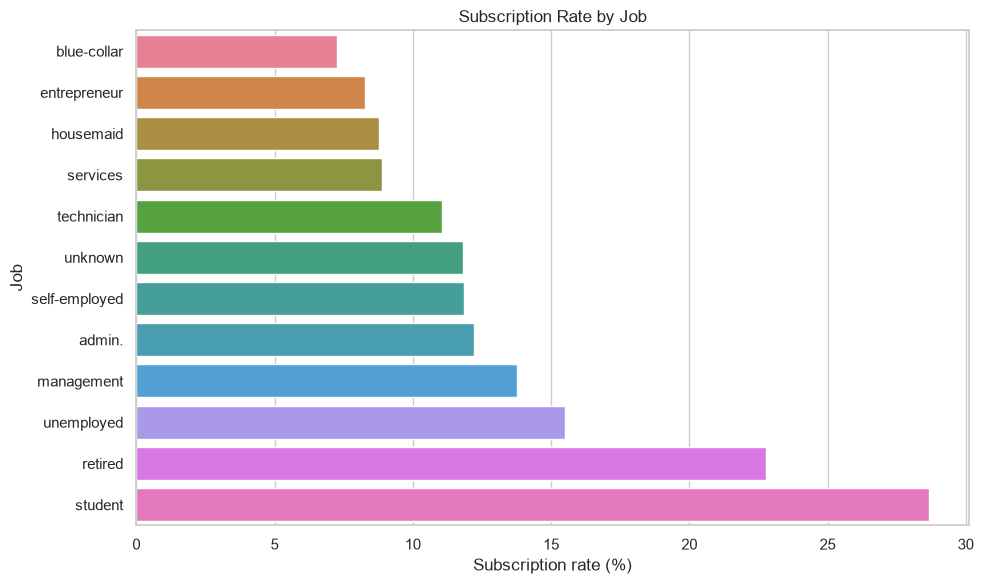

In [58]:
job_plot_data = (
    job_summary
    .sort_values(
        "subscription_rate",
        ascending=True,
    )
)

figure, axis = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=job_plot_data,
    x="subscription_rate",
    y="job",
    hue="job",
    legend=False,
    ax=axis,
)

axis.set_title("Subscription Rate by Job")
axis.set_xlabel("Subscription rate (%)")
axis.set_ylabel("Job")

plt.tight_layout()
plt.show()

## 7. Subscription Rate by Education and Marital Status

Education and marital status may help describe customer segments, but the observed differences should not be interpreted as causal effects.

The `unknown` education category is retained because its meaning is operationally different from a standard null value.

In [59]:
education_order = [
    "unknown",
    "primary",
    "secondary",
    "tertiary",
]

education_summary = subscription_summary_by_category(
    data,
    "education",
    category_order=education_order,
)

display(education_summary)

,education,client_count,subscriber_count,subscription_rate,share_of_all_clients
0,unknown,1857,252,13.57,4.11
1,primary,6851,591,8.63,15.15
2,secondary,23202,2450,10.56,51.32
3,tertiary,13301,1996,15.01,29.42


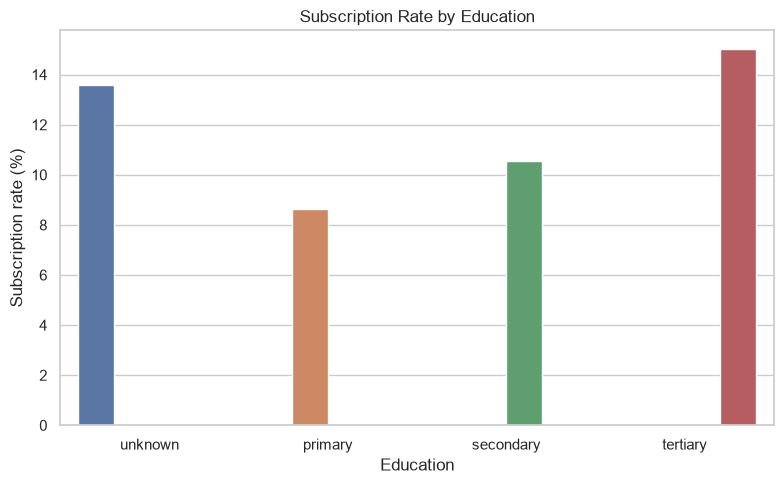

In [60]:
figure, axis = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=education_summary,
    x="education",
    y="subscription_rate",
    hue="education",
    legend=False,
    ax=axis,
)

axis.set_title("Subscription Rate by Education")
axis.set_xlabel("Education")
axis.set_ylabel("Subscription rate (%)")

plt.tight_layout()
plt.show()

In [61]:
marital_summary = subscription_summary_by_category(
    data,
    "marital",
)

display(marital_summary)

,marital,client_count,subscriber_count,subscription_rate,share_of_all_clients
0,single,12790,1912,14.95,28.29
1,divorced,5207,622,11.95,11.52
2,married,27214,2755,10.12,60.19


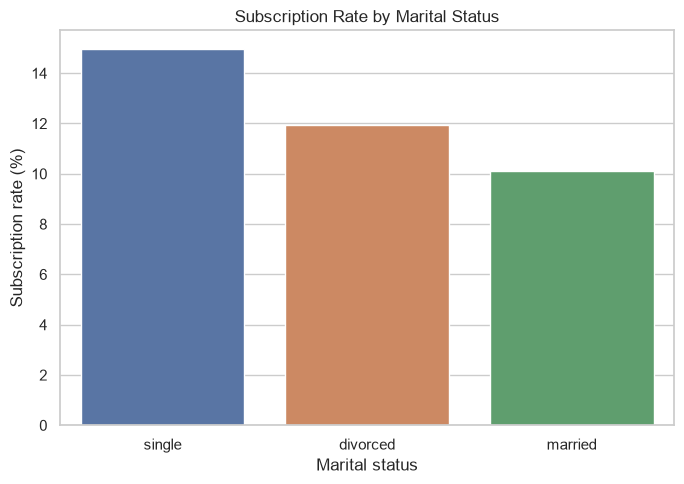

In [62]:
figure, axis = plt.subplots(figsize=(7, 5))

sns.barplot(
    data=marital_summary,
    x="marital",
    y="subscription_rate",
    hue="marital",
    legend=False,
    ax=axis,
)

axis.set_title("Subscription Rate by Marital Status")
axis.set_xlabel("Marital status")
axis.set_ylabel("Subscription rate (%)")

plt.tight_layout()
plt.show()

## 8. Communication Channel and Campaign Timing

The contact channel and campaign month may be associated with different subscription rates.

However, these patterns may reflect customer selection, campaign strategy, seasonality, or other operational factors. They should not automatically be interpreted as the independent effect of the channel or month.

In [63]:
contact_summary = subscription_summary_by_category(
    data,
    "contact",
)

display(contact_summary)

,contact,client_count,subscriber_count,subscription_rate,share_of_all_clients
0,cellular,29285,4369,14.92,64.77
1,telephone,2906,390,13.42,6.43
2,unknown,13020,530,4.07,28.80


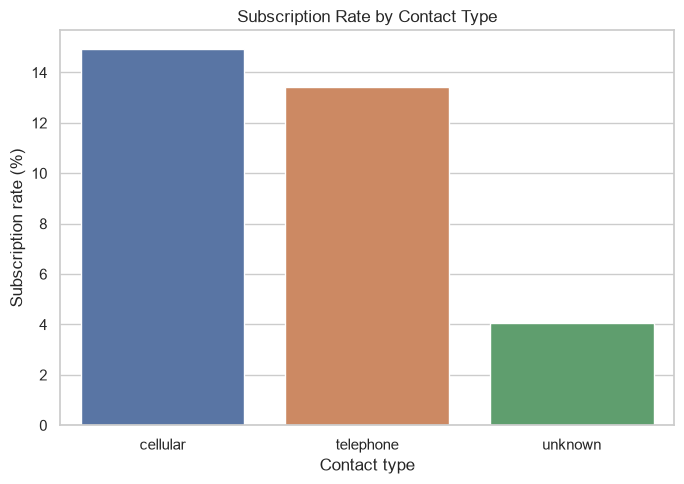

In [64]:
figure, axis = plt.subplots(figsize=(7, 5))

sns.barplot(
    data=contact_summary,
    x="contact",
    y="subscription_rate",
    hue="contact",
    legend=False,
    ax=axis,
)

axis.set_title("Subscription Rate by Contact Type")
axis.set_xlabel("Contact type")
axis.set_ylabel("Subscription rate (%)")

plt.tight_layout()
plt.show()

In [65]:
month_order = [
    "jan",
    "feb",
    "mar",
    "apr",
    "may",
    "jun",
    "jul",
    "aug",
    "sep",
    "oct",
    "nov",
    "dec",
]

month_summary = subscription_summary_by_category(
    data,
    "month",
    category_order=month_order,
)

display(month_summary)

,month,client_count,subscriber_count,subscription_rate,share_of_all_clients
0,jan,1403,142,10.12,3.10
1,feb,2649,441,16.65,5.86
2,mar,477,248,51.99,1.06
3,apr,2932,577,19.68,6.49
4,may,13766,925,6.72,30.45
5,jun,5341,546,10.22,11.81
6,jul,6895,627,9.09,15.25
7,aug,6247,688,11.01,13.82
8,sep,579,269,46.46,1.28
9,oct,738,323,43.77,1.63


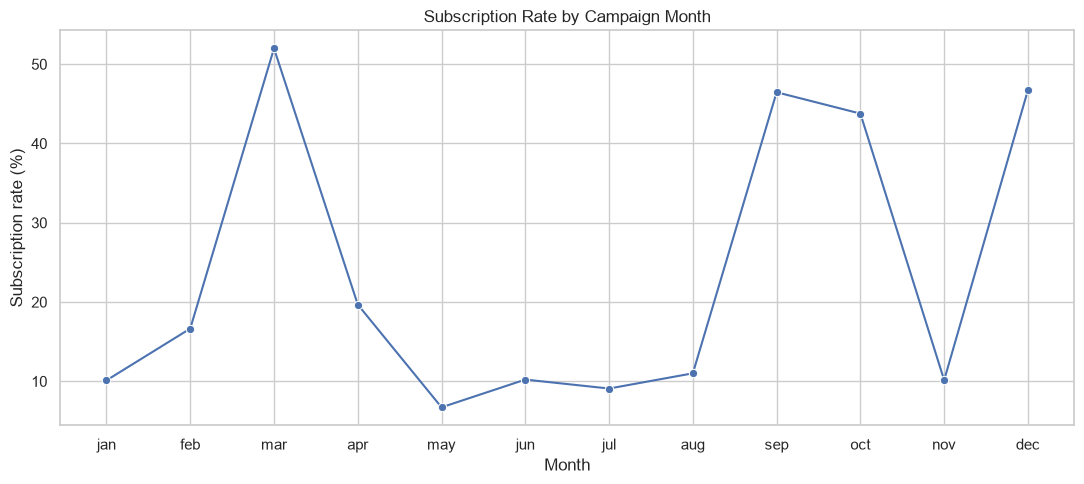

In [66]:
figure, axis = plt.subplots(figsize=(11, 5))

sns.lineplot(
    data=month_summary,
    x="month",
    y="subscription_rate",
    marker="o",
    ax=axis,
)

axis.set_title("Subscription Rate by Campaign Month")
axis.set_xlabel("Month")
axis.set_ylabel("Subscription rate (%)")

plt.tight_layout()
plt.show()

## 9. Previous Campaign Outcome

The previous campaign outcome may provide important information about customer history.

The `unknown` category is very common and often reflects clients with no meaningful previous campaign result. It is retained rather than imputed or removed.

In [67]:
poutcome_summary = subscription_summary_by_category(
    data,
    "poutcome",
)

display(poutcome_summary)

,poutcome,client_count,subscriber_count,subscription_rate,share_of_all_clients
0,success,1511,978,64.73,3.34
1,other,1840,307,16.68,4.07
2,failure,4901,618,12.61,10.84
3,unknown,36959,3386,9.16,81.75


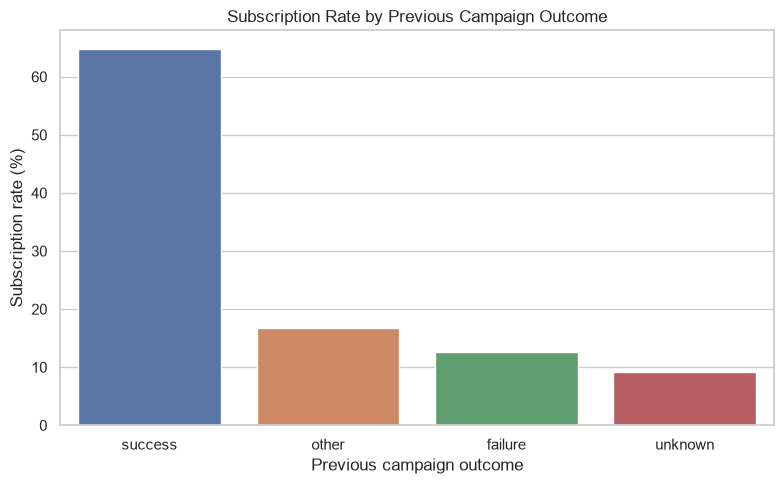

In [68]:
figure, axis = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=poutcome_summary,
    x="poutcome",
    y="subscription_rate",
    hue="poutcome",
    legend=False,
    ax=axis,
)

axis.set_title(
    "Subscription Rate by Previous Campaign Outcome"
)
axis.set_xlabel("Previous campaign outcome")
axis.set_ylabel("Subscription rate (%)")

plt.tight_layout()
plt.show()

### Interpretation Caution

A previous successful campaign outcome may be strongly associated with a new subscription.

This does not prove that the previous campaign caused the new subscription. It may also indicate persistent customer interest, previous targeting decisions, or unobserved customer characteristics.

## 10. Customer and Financial Segmentation

Continuous variables such as age and account balance are grouped into interpretable business segments.

These groups make it easier to compare conversion rates, but the boundaries are descriptive choices rather than naturally occurring customer categories.

In [69]:
analysis_data = data.copy()

In [70]:
age_group_order = [
    "18-29",
    "30-39",
    "40-49",
    "50-59",
    "60-69",
    "70+",
]

analysis_data["age_group"] = pd.cut(
    analysis_data["age"],
    bins=[17, 29, 39, 49, 59, 69, np.inf],
    labels=age_group_order,
    include_lowest=True,
)

assert analysis_data["age_group"].notna().all()

age_summary = subscription_summary_by_category(
    analysis_data,
    "age_group",
    category_order=age_group_order,
)

display(age_summary)

,age_group,client_count,subscriber_count,subscription_rate,share_of_all_clients
0,18-29,5273,928,17.60,11.66
1,30-39,18089,1913,10.58,40.01
2,40-49,11655,1063,9.12,25.78
3,50-59,8410,785,9.33,18.60
4,60-69,1230,365,29.67,2.72
5,70+,554,235,42.42,1.23


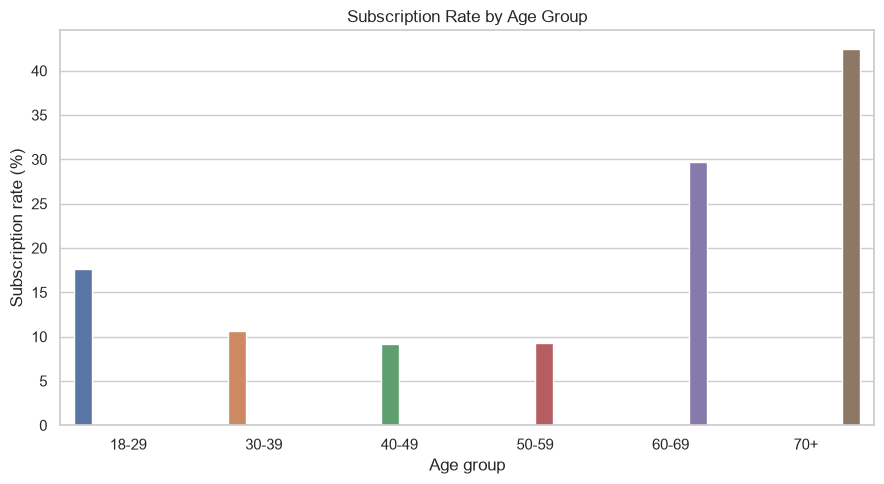

In [71]:
figure, axis = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=age_summary,
    x="age_group",
    y="subscription_rate",
    hue="age_group",
    legend=False,
    ax=axis,
)

axis.set_title("Subscription Rate by Age Group")
axis.set_xlabel("Age group")
axis.set_ylabel("Subscription rate (%)")

plt.tight_layout()
plt.show()

## 11. Account-Balance Segments

Account balances are divided into business-friendly groups.

Negative balances are retained because they may represent legitimate overdrafts or debt rather than data errors.

In [72]:
balance_group_order = [
    "Negative balance",
    "Zero balance",
    "1-1,000",
    "1,001-5,000",
    "Above 5,000",
]

balance_conditions = [
    analysis_data["balance"] < 0,
    analysis_data["balance"] == 0,
    analysis_data["balance"].between(1, 1_000),
    analysis_data["balance"].between(1_001, 5_000),
    analysis_data["balance"] > 5_000,
]

analysis_data["balance_group"] = np.select(
    balance_conditions,
    balance_group_order,
    default="Unclassified",
)

assert (
    analysis_data["balance_group"] != "Unclassified"
).all()

analysis_data["balance_group"] = pd.Categorical(
    analysis_data["balance_group"],
    categories=balance_group_order,
    ordered=True,
)

balance_summary = subscription_summary_by_category(
    analysis_data,
    "balance_group",
    category_order=balance_group_order,
)

display(balance_summary)

,balance_group,client_count,subscriber_count,subscription_rate,share_of_all_clients
0,Negative balance,3766,210,5.58,8.33
1,Zero balance,3514,292,8.31,7.77
2,"1-1,000",23300,2539,10.90,51.54
3,"1,001-5,000",11786,1807,15.33,26.07
4,"Above 5,000",2845,441,15.50,6.29


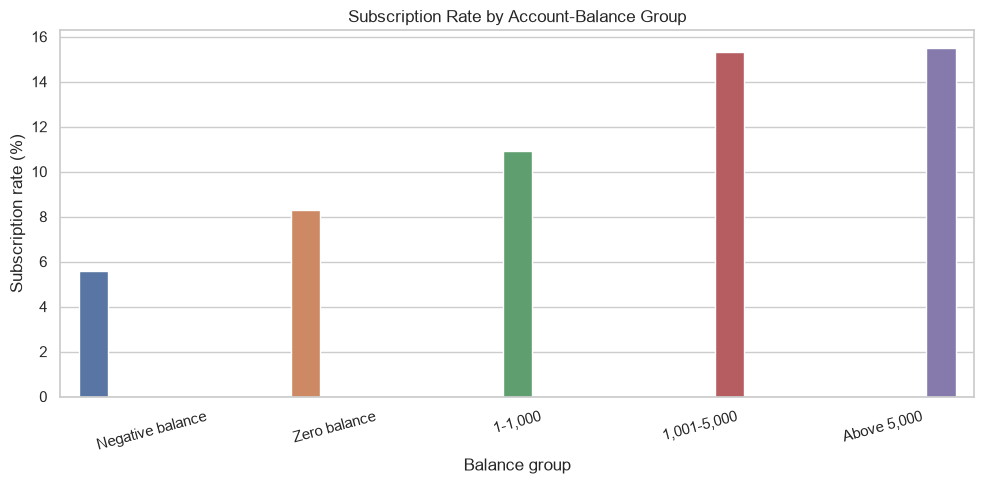

In [73]:
figure, axis = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=balance_summary,
    x="balance_group",
    y="subscription_rate",
    hue="balance_group",
    legend=False,
    ax=axis,
)

axis.set_title("Subscription Rate by Account-Balance Group")
axis.set_xlabel("Balance group")
axis.set_ylabel("Subscription rate (%)")
axis.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 12. Campaign Contact Intensity

The `campaign` feature represents the number of contacts made during the current campaign for the client.

Repeated contacts may reflect campaign persistence, difficult-to-reach customers, customer fatigue, or operational targeting decisions.

The observed relationship is descriptive and should not automatically be interpreted as the causal effect of additional calls.

In [74]:
campaign_group_order = [
    "1 contact",
    "2-3 contacts",
    "4-5 contacts",
    "6-10 contacts",
    "11+ contacts",
]

analysis_data["campaign_group"] = pd.cut(
    analysis_data["campaign"],
    bins=[0, 1, 3, 5, 10, np.inf],
    labels=campaign_group_order,
    include_lowest=True,
)

assert analysis_data["campaign_group"].notna().all()

campaign_summary = subscription_summary_by_category(
    analysis_data,
    "campaign_group",
    category_order=campaign_group_order,
)

display(campaign_summary)

,campaign_group,client_count,subscriber_count,subscription_rate,share_of_all_clients
0,1 contact,17544,2561,14.60,38.80
1,2-3 contacts,18026,2019,11.20,39.87
2,4-5 contacts,5286,456,8.63,11.69
3,6-10 contacts,3159,206,6.52,6.99
4,11+ contacts,1196,47,3.93,2.65


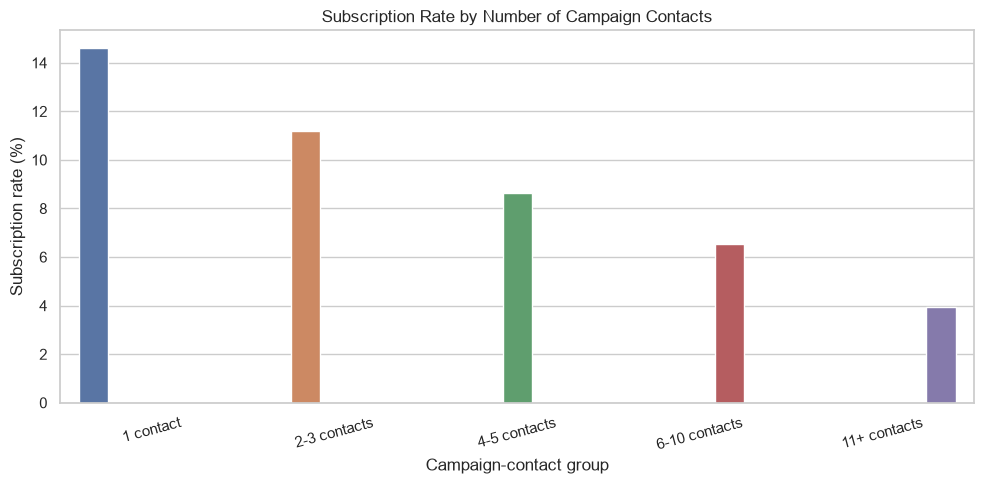

In [75]:
figure, axis = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=campaign_summary,
    x="campaign_group",
    y="subscription_rate",
    hue="campaign_group",
    legend=False,
    ax=axis,
)

axis.set_title(
    "Subscription Rate by Number of Campaign Contacts"
)
axis.set_xlabel("Campaign-contact group")
axis.set_ylabel("Subscription rate (%)")
axis.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 13. Existing Financial Obligations

Housing-loan and personal-loan indicators may describe differences in customers' financial commitments and willingness to subscribe to a term deposit.

These comparisons remain observational and do not demonstrate that a loan directly changes subscription behavior.

In [76]:
housing_summary = subscription_summary_by_category(
    analysis_data,
    "housing",
)

display(housing_summary)

,housing,client_count,subscriber_count,subscription_rate,share_of_all_clients
0,no,20081,3354,16.70,44.42
1,yes,25130,1935,7.70,55.58


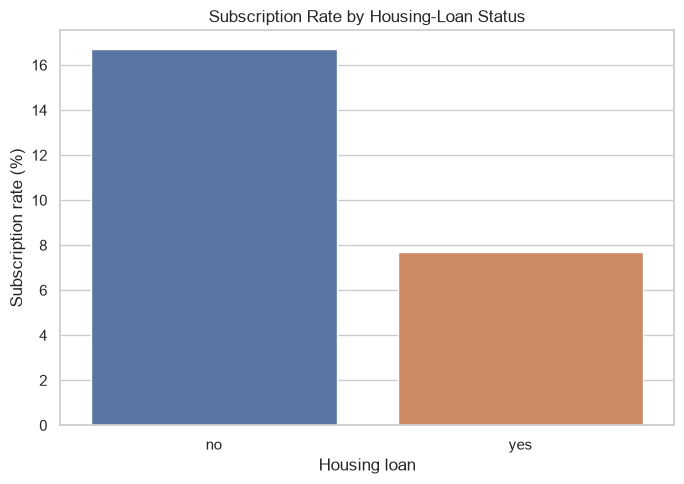

In [77]:
figure, axis = plt.subplots(figsize=(7, 5))

sns.barplot(
    data=housing_summary,
    x="housing",
    y="subscription_rate",
    hue="housing",
    legend=False,
    ax=axis,
)

axis.set_title("Subscription Rate by Housing-Loan Status")
axis.set_xlabel("Housing loan")
axis.set_ylabel("Subscription rate (%)")

plt.tight_layout()
plt.show()

In [78]:
loan_summary = subscription_summary_by_category(
    analysis_data,
    "loan",
)

display(loan_summary)

,loan,client_count,subscriber_count,subscription_rate,share_of_all_clients
0,no,37967,4805,12.66,83.98
1,yes,7244,484,6.68,16.02


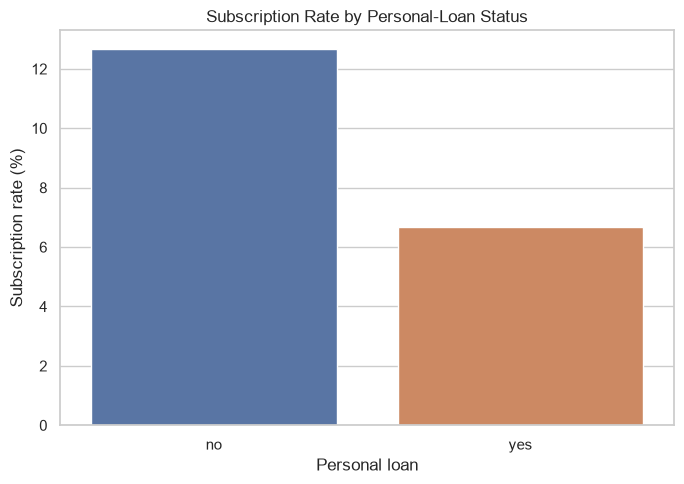

In [79]:
figure, axis = plt.subplots(figsize=(7, 5))

sns.barplot(
    data=loan_summary,
    x="loan",
    y="subscription_rate",
    hue="loan",
    legend=False,
    ax=axis,
)

axis.set_title("Subscription Rate by Personal-Loan Status")
axis.set_xlabel("Personal loan")
axis.set_ylabel("Subscription rate (%)")

plt.tight_layout()
plt.show()

## 14. Call Duration and Data Leakage

Call duration is analyzed because it provides useful descriptive information about completed campaign calls.

However, call duration is not known before the call ends. Therefore:

- It can help explain historical outcomes.
- It cannot be used to select clients before calling them.
- It will be excluded from the primary deployable pre-call model.
- A model that includes it may achieve misleadingly strong predictive performance.

This is a temporal form of data leakage: information available only after the decision point is used to predict an earlier decision.

In [80]:
duration_by_target = (
    analysis_data
    .groupby(TARGET_COLUMN)["duration"]
    .agg(
        client_count="size",
        mean_duration="mean",
        median_duration="median",
        minimum_duration="min",
        maximum_duration="max",
    )
    .reset_index()
)

duration_by_target["subscription_label"] = (
    duration_by_target[TARGET_COLUMN]
    .map(
        {
            0: "No subscription",
            1: "Subscription",
        }
    )
)

display(duration_by_target)

,subscribed,client_count,mean_duration,median_duration,minimum_duration,maximum_duration,subscription_label
0,0,39922,221.18,164.00,0,4918,No subscription
1,1,5289,537.29,426.00,8,3881,Subscription


In [81]:
analysis_data["duration_decile"] = pd.qcut(
    analysis_data["duration"],
    q=10,
    duplicates="drop",
)

duration_decile_summary = (
    analysis_data
    .groupby(
        "duration_decile",
        observed=True,
    )[TARGET_COLUMN]
    .agg(
        client_count="size",
        subscriber_count="sum",
        subscription_rate="mean",
    )
    .reset_index()
)

duration_decile_summary["subscription_rate"] = (
    duration_decile_summary["subscription_rate"]
    .mul(100)
    .round(2)
)

duration_decile_summary["duration_range"] = (
    duration_decile_summary["duration_decile"]
    .astype(str)
)

display(
    duration_decile_summary[
        [
            "duration_range",
            "client_count",
            "subscriber_count",
            "subscription_rate",
        ]
    ]
)

,duration_range,client_count,subscriber_count,subscription_rate
0,"(-0.001, 58.0]",4529,9,0.20
1,"(58.0, 89.0]",4576,57,1.25
2,"(89.0, 117.0]",4495,128,2.85
3,"(117.0, 147.0]",4564,209,4.58
4,"(147.0, 180.0]",4496,306,6.81
5,"(180.0, 223.0]",4531,410,9.05
6,"(223.0, 280.0]",4517,557,12.33
7,"(280.0, 368.0]",4468,616,13.79
8,"(368.0, 548.0]",4527,944,20.85
9,"(548.0, 4918.0]",4508,2053,45.54


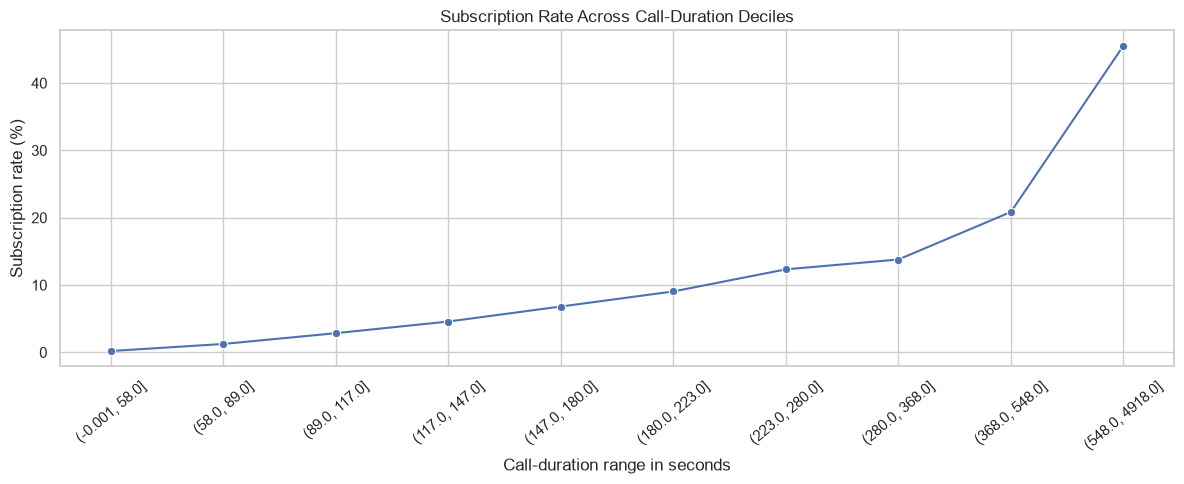

In [82]:
figure, axis = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=duration_decile_summary,
    x="duration_range",
    y="subscription_rate",
    marker="o",
    ax=axis,
)

axis.set_title(
    "Subscription Rate Across Call-Duration Deciles"
)
axis.set_xlabel("Call-duration range in seconds")
axis.set_ylabel("Subscription rate (%)")
axis.tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()

## 15. Numerical Correlation Analysis

Spearman correlation is used because several numerical variables are highly skewed, contain sentinel values, or have non-linear monotonic relationships.

Correlation measures association rather than causation. Correlations involving the binary target are descriptive and should not replace model-based evaluation or statistical testing.

In [83]:
correlation_columns = (
    NUMERIC_COLUMNS
    + [TARGET_COLUMN]
)

spearman_correlation = (
    analysis_data[correlation_columns]
    .corr(method="spearman")
)

target_correlations = (
    spearman_correlation[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .rename("spearman_correlation_with_target")
    .reset_index()
    .rename(columns={"index": "feature"})
)

target_correlations["absolute_correlation"] = (
    target_correlations[
        "spearman_correlation_with_target"
    ].abs()
)

target_correlations = (
    target_correlations
    .sort_values(
        "absolute_correlation",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(target_correlations)

,feature,spearman_correlation_with_target,absolute_correlation
0,duration,0.34,0.34
1,previous,0.17,0.17
2,pdays,0.15,0.15
3,balance,0.10,0.10
4,campaign,-0.08,0.08
5,day,-0.03,0.03
6,age,-0.01,0.01


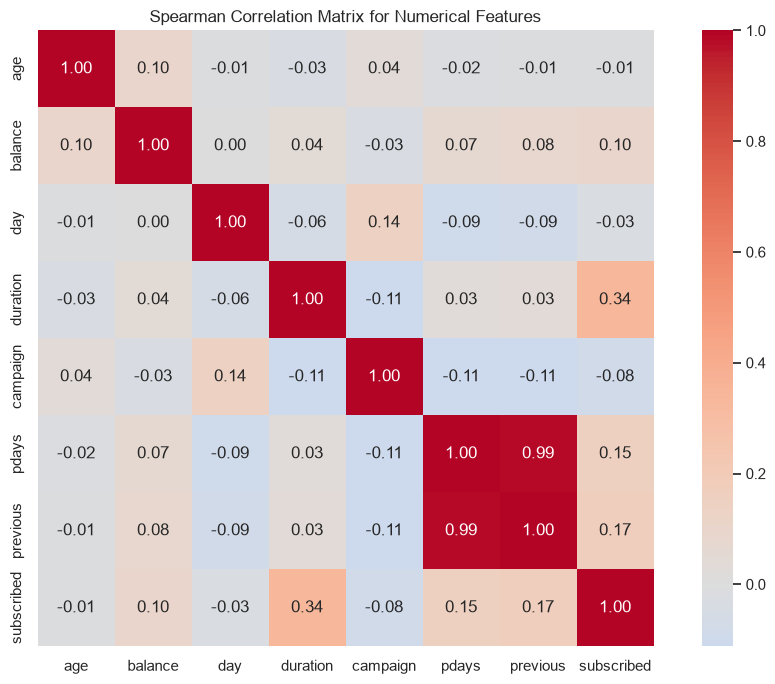

In [84]:
figure, axis = plt.subplots(figsize=(10, 7))

sns.heatmap(
    spearman_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=axis,
)

axis.set_title(
    "Spearman Correlation Matrix for Numerical Features"
)

plt.tight_layout()
plt.show()

## 16. Business-Oriented Segment Summary

The highest conversion rate is not always the most operationally useful result.

To avoid highlighting extremely small groups, the following summary considers only segments containing at least 1% of all clients. This balances conversion rate with potential campaign scale.

In [85]:
MINIMUM_SEGMENT_SIZE = int(
    len(analysis_data) * 0.01
)

print(
    "Minimum segment size used:",
    MINIMUM_SEGMENT_SIZE,
)

Minimum segment size used: 452


In [86]:
def select_best_scalable_segment(
    summary: pd.DataFrame,
    feature: str,
) -> dict[str, object]:
    """Select the highest-rate segment with sufficient size."""
    eligible_segments = summary.loc[
        summary["client_count"]
        >= MINIMUM_SEGMENT_SIZE
    ].copy()

    if eligible_segments.empty:
        raise ValueError(
            f"No eligible segments found for {feature}."
        )

    best_segment = (
        eligible_segments
        .sort_values(
            [
                "subscription_rate",
                "subscriber_count",
            ],
            ascending=[False, False],
        )
        .iloc[0]
    )

    return {
        "feature": feature,
        "segment": str(best_segment[feature]),
        "client_count": int(
            best_segment["client_count"]
        ),
        "subscriber_count": int(
            best_segment["subscriber_count"]
        ),
        "subscription_rate": float(
            best_segment["subscription_rate"]
        ),
    }


scalable_segment_findings = pd.DataFrame(
    [
        select_best_scalable_segment(
            job_summary,
            "job",
        ),
        select_best_scalable_segment(
            contact_summary,
            "contact",
        ),
        select_best_scalable_segment(
            month_summary,
            "month",
        ),
        select_best_scalable_segment(
            poutcome_summary,
            "poutcome",
        ),
        select_best_scalable_segment(
            age_summary,
            "age_group",
        ),
        select_best_scalable_segment(
            balance_summary,
            "balance_group",
        ),
        select_best_scalable_segment(
            campaign_summary,
            "campaign_group",
        ),
    ]
)

display(scalable_segment_findings)

,feature,segment,client_count,subscriber_count,subscription_rate
0,job,student,938,269,28.68
1,contact,cellular,29285,4369,14.92
2,month,mar,477,248,51.99
3,poutcome,success,1511,978,64.73
4,age_group,70+,554,235,42.42
5,balance_group,"Above 5,000",2845,441,15.50
6,campaign_group,1 contact,17544,2561,14.60


## 17. Exploratory-Analysis Validation

The following checks confirm that the segmentation and exploratory calculations preserve the full dataset and produce valid subscription rates.

In [87]:
assert len(analysis_data) == 45_211

assert analysis_data["age_group"].notna().all()
assert analysis_data["balance_group"].notna().all()
assert analysis_data["campaign_group"].notna().all()
assert analysis_data["duration_decile"].notna().all()

assert age_summary["client_count"].sum() == len(
    analysis_data
)

assert balance_summary["client_count"].sum() == len(
    analysis_data
)

assert campaign_summary["client_count"].sum() == len(
    analysis_data
)

assert housing_summary["client_count"].sum() == len(
    analysis_data
)

assert loan_summary["client_count"].sum() == len(
    analysis_data
)

assert duration_decile_summary[
    "client_count"
].sum() == len(analysis_data)

summary_tables = [
    age_summary,
    balance_summary,
    campaign_summary,
    housing_summary,
    loan_summary,
    duration_decile_summary,
]

for summary_table in summary_tables:
    assert summary_table[
        "subscription_rate"
    ].between(0, 100).all()

assert len(scalable_segment_findings) == 7

print(
    "All exploratory-data-analysis "
    "validation checks passed successfully."
)

All exploratory-data-analysis validation checks passed successfully.


## 18. EDA Summary

The exploratory analysis examined customer demographics, account characteristics, financial obligations, campaign timing, contact intensity, previous campaign history, and subscription outcomes.

Main methodological conclusions:

- The target is imbalanced, with subscribers representing approximately 11.7% of records.
- Several numerical features are highly skewed, so medians and robust summaries are important.
- Segment-level subscription rates must be interpreted together with segment size.
- Existing associations are observational and should not be described as causal effects.
- Explicit `unknown` categories were retained and analyzed as operational categories.
- Potential outliers were not automatically removed.
- `duration` is descriptively informative but will be excluded from the primary pre-call model because it creates temporal data leakage.
- Statistical tests will be used later to evaluate selected relationships and effect sizes.
- Multivariable machine-learning models will later assess predictive patterns while controlling for combinations of features.

The cleaned dataset and EDA findings are ready for SQL-based business analysis.